In [87]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import random
import math

In [88]:
MRG_TABLE = {
    5.7:  (0.605, 3.4, 1.9, 1.9, 3.4,  500, 35,  80),
    7.3:  (0.630, 4.6, 2.4, 2.4, 4.6,  750, 38, 100),
    8.7:  (0.661, 5.8, 2.8, 2.8, 5.8, 1000, 40, 110),
    10.0: (0.690, 6.9, 3.3, 3.3, 6.9, 1150, 46, 120),
    11.5: (0.700, 8.1, 3.7, 3.7, 8.1, 1250, 50, 130),
    12.8: (0.719, 9.2, 4.2, 4.2, 9.2, 1350, 54, 135),
    14.0: (0.739,10.4, 4.7, 4.7,10.4, 1400, 56, 140),
    15.0: (0.767,11.5, 5.0, 5.0,11.5, 1450, 58, 145),
    16.0: (0.791,12.7, 5.5, 5.5,12.7, 1500, 60, 150),
}

In [89]:
class MRGaxon:

    h.load_file('stdrun.hoc')
    # ---------- ГЛОБАЛЬНЫЕ ПАРАМЕТРЫ ----------
    celsius = 37.0
    dt_ms   = 0.05
    v_init  = -80.0

    # Электрические константы, как в MRG
    rho_a = 0.7e6  # Ohm·um
    mycm = 0.1    # uF/cm2 per lamella
    mygm = 0.001  # S/cm2 per lamella

    # Периакисональные зазоры (ум)
    space_p1 = 0.002  # вокруг узла/MYSA
    space_p2 = 0.004  # вокруг FLUT
    space_i  = 0.004  # вокруг STIN

    # Геометрия "минимал" MRG
    paralength1 = 3.0   # MYSA длина (ум)
    nodelength  = 1.0   # узел (ум)

    gna_axnode = 3.0 # Проводимость
    bouton_L = 1 # мкм

    def __init__(self,
             fiber_diameter=10.0,
             parent_axon_nodes=42,
             branch_nodes=21,
             branches_num=2,
             nodes_dist=10,
             diam_scale=0.6,
             celsius=37.0,
             dt_ms=0.05,
             v_init=-80.0,
             h_stop = 1000.0):

        self.reset_model()

        # Параметры морфологии
        self.fiber_diameter = fiber_diameter

        self.parent_axon_nodes = parent_axon_nodes
        self.branch_nodes = branch_nodes
        self.branches_num = branches_num
        self.nodes_dist = nodes_dist
        self.diam_scale = diam_scale

        # Параметры симуляции
        self.celsius = celsius
        self.dt_ms = dt_ms
        self.v_init = v_init

        # Установка глобальных параметров NEURON
        h.celsius = celsius
        h.dt = dt_ms

        # Реестры секций
        self.regions = {
            "node": [],
            "mysa": [],
            "flut": [],
            "stin": []
        }

        # Счётчики ID
        self._node_id = 0
        self._mysa_id = 0
        self._flut_id = 0
        self._stin_id = 0

        # Структуры аксона
        self.main_axon = []
        self.branches = []  # Список ветвей, каждая ветвь - список узлов
        self.terminals = []

        # Параметры стимуляции по умолчанию
        self.stimulation_params = {
            'freq_hz': 10,
            'amp': 0.8,
            't_start': 200.0,
            't_end': 1000.0,
            'pulse_len_ms': 1.0,
            'phase_ms': 0.0
        }
        self.h_stop = h_stop

        h.tstop = self.h_stop

        # Механизм узла
        self.node_mech = self._pick_node_mech()

        # Получение параметров MRG
        self.mrg_params = self._get_mrg_params(fiber_diameter)

        # Построение аксона
        self.build_axon()



    def reset_model(self):
        # удалить все секции из ядра NEURON
        h('forall delete_section()')


    def _pick_node_mech(self):
        """Автовыбор доступного нодального механизма."""
        tmp = h.Section()
        try:
            tmp.insert('newaxnode')
            tmp.uninsert('newaxnode')
            return 'newaxnode'
        except:
            pass
        try:
            tmp.insert('axnode')
            tmp.uninsert('axnode')
            return 'axnode'
        except:
            pass
        raise RuntimeError("Не найден ни 'newaxnode', ни 'axnode' — скомпилируйте .mod файлы.")

    def _get_mrg_params(self, fiberD):
        """Получает параметры MRG для заданного диаметра волокна."""
        if fiberD not in MRG_TABLE:
            raise ValueError(f"fiberD {fiberD} не в таблице.")

        g, axon_d, node_d, para_d1, para_d2, deltax, paralength2, nl = MRG_TABLE[fiberD]
        interlength = (deltax - self.nodelength - 2 * self.paralength1 - 2 * paralength2) / 6.0

        return {
            'fiberD': fiberD,
            'axonD': axon_d,
            'nodeD': node_d,
            'paraD1': para_d1,
            'paraD2': para_d2,
            'paral1': self.paralength1,
            'paral2': paralength2,
            'interL': interlength,
            'nl': nl,
            'rpn0': self._rin_peri(node_d, self.space_p1),
            'rpn1': self._rin_peri(para_d1, self.space_p1),
            'rpn2': self._rin_peri(para_d2, self.space_p2),
            'rpx': self._rin_peri(axon_d, self.space_i),
            'Lstep': 2 * self.paralength1 + 2 * paralength2 + 6 * interlength + self.nodelength
        }

    def _rin_peri(self, inner_d_um, gap_um):
        """Продольное сопротивление периаксонального пространства."""
        return (self.rho_a*0.01)/(math.pi*(((inner_d_um/2+gap_um)**2) - (inner_d_um/2)**2))

    def _insert_mechanism(self, sec, mech_name):
        """Вставляет механизм в секцию, если его ещё нет."""
        if int(h.ismembrane(mech_name, sec=sec)) == 0:
            sec.insert(mech_name)

    def _set_extracellular(self, sec, xraxial, xg, xc):
        """Устанавливает extracellular-параметры."""
        self._insert_mechanism(sec, 'extracellular')
        for seg in sec:
            seg.xraxial[0] = xraxial
            seg.xg[0] = xg
            seg.xc[0] = xc

    # ---------- КОНСТРУКТОРЫ СЕКЦИЙ ----------
    def make_node(self, nodeD, nodel, Rpn0, gnabar=3.0, gnapbar=0.005, el=-90.0):

        s = h.Section(name=f'node_{self._node_id}')
        self._node_id +=1
        s.nseg = 1
        s.L    = nodel
        s.diam = nodeD
        s.Ra   = self.rho_a/10000.0
        s.cm   = 2.0

        self._insert_mechanism(s, self.node_mech)

        if self.node_mech == 'newaxnode':
            s.el_newaxnode      = -90.0 if el is None else el
            s.gnabar_newaxnode  = 3.0   if gnabar  is None else gnabar
            s.gnapbar_newaxnode = 0.005 if gnapbar is None else gnapbar
        self._set_extracellular(s, Rpn0, 1e10, 0.0)
        self.regions["node"].append(s)
        return s

    def make_mysa(self, fiberD, paraD1, paral1, nl, rpn1):

        s = h.Section(name=f'MYSA_{self._mysa_id}')

        self._mysa_id += 1

        s.nseg = 1
        s.L    = paral1
        s.diam = fiberD
        ratio  = paraD1/fiberD
        s.Ra   = self.rho_a*(1.0/(ratio*ratio))/10000.0
        s.cm   = 2.0*ratio

        self._insert_mechanism(s, 'pas')
        s.g_pas = 0.001*ratio
        s.e_pas = -80.0

        self._set_extracellular(s, rpn1, self.mygm / (nl * 2.0), self.mycm / (nl * 2.0))
        self.regions["mysa"].append(s)
        return s

    def make_flut(self, fiberD, paraD2, paral2, nl, rpn2):

        s = h.Section(name=f'FLUT_{self._flut_id}')
        self._flut_id += 1

        s.nseg = 1
        s.L    = paral2
        s.diam = fiberD
        ratio  = paraD2/fiberD
        s.Ra   = self.rho_a*(1.0/(ratio*ratio))/10000.0
        s.cm   = 2.0*ratio

        self._insert_mechanism(s, 'pas')
        s.g_pas = 0.0001*ratio
        s.e_pas = -80.0
        self._set_extracellular(s, rpn2, self.mygm / (nl * 2.0), self.mycm / (nl * 2.0))
        self.regions["flut"].append(s)

        return s

    def make_stin(self, fiberD, axonD, interL, nl, rpx):

        s = h.Section(name=f'STIN_{self._stin_id}')
        self._stin_id += 1

        s.nseg = 1
        s.L    = interL
        s.diam = fiberD
        ratio  = axonD/fiberD
        s.Ra   = self.rho_a*(1.0/(ratio*ratio))/10000.0
        s.cm   = 2.0*ratio
        self._insert_mechanism(s, 'pas')
        s.g_pas = 0.0001*ratio
        s.e_pas = -80.0
        self._set_extracellular(s, rpx, self.mygm / (nl * 2.0), self.mycm / (nl * 2.0))
        self.regions["stin"].append(s)
        return s


    # ---------- ОДИН ШАГ MRG (между узлами): MYSA→FLUT→STIN×6→FLUT→MYSA→node ----------

    def append_one_step(self, parent_node, params):

        mysa0 = self.make_mysa(params['fiberD'], params['paraD1'], params['paral1'], params['nl'], params['rpn1'])
        flut0 = self.make_flut(params['fiberD'], params['paraD2'], params['paral2'], params['nl'], params['rpn2'])
        stin_sections = [self.make_stin(params['fiberD'], params['axonD'], params['interL'], params['nl'], params['rpx']) for _ in range(6)]
        flut1 = self.make_flut(params['fiberD'], params['paraD2'], params['paral2'], params['nl'], params['rpn2'])
        mysa1 = self.make_mysa(params['fiberD'], params['paraD1'], params['paral1'], params['nl'], params['rpn1'])
        next_node   = self.make_node(params['nodeD'], self.nodelength, params['rpn0'])

        # топология
        mysa0.connect(parent_node, 1.0, 0.0)
        flut0.connect(mysa0,       1.0, 0.0)
        stin_sections[0].connect(flut0,       1.0, 0.0)
        for k in range(1,6):
            stin_sections[k].connect(stin_sections[k-1], 1.0, 0.0)
        flut1.connect(stin_sections[5],       1.0, 0.0)
        mysa1.connect(flut1,       1.0, 0.0)
        next_node.connect(mysa1,         1.0, 0.0)

        return next_node

    def build_chain(self, n_nodes, params, node_mech=None):
        nodes = [self.make_node(params['nodeD'], self.nodelength, params['Rpn0'])]
        for _ in range(n_nodes-1):
            next_node = self.append_one_step(nodes[-1], params)
            nodes.append(next_node)

        return nodes

    def scaled_params(self, params, diam_scale=0.6):
        """Сужение диаметров после ветвления."""
        scaled = params.copy()

        scaled['fiberD'] *= diam_scale
        scaled['axonD']  *= diam_scale
        scaled['nodeD']  *= diam_scale
        scaled['paraD1'] *= diam_scale
        scaled['paraD2'] *= diam_scale

        scaled['Rpn0'] = self._rin_peri(scaled['nodeD'],  self.space_p1)
        scaled['Rpn1'] = self._rin_peri(scaled['paraD1'], self.space_p1)
        scaled['Rpn2'] = self._rin_peri(scaled['paraD2'], self.space_p2)
        scaled['Rpx']  = self._rin_peri(scaled['axonD'],  self.space_i)

        return scaled


    def build_axon(self):

        terminals = []
        params = self.mrg_params
        #P0 = mrg_params(fiberD=10)
        #P_curr = dict(P0)
        #print("P0", P0, "P_curr", P_curr)

        #main_axon = [make_node(params['nodeD'], nodelength, rhoa, params['Rpn0'], NODE_MECH)]

        self.main_axon = [self.make_node(self.mrg_params['nodeD'], self.nodelength, self.mrg_params['rpn0'])]

        node_D_after_branching = False
        count_nodes_after_branching = 0
        nodes = 0

        self.branch_point_id = []
        self.before_branch_id = []
        self.after_branch_main_id = []
        self.after_branch_daughter_id = []

        for _ in range(self.parent_axon_nodes-1):

            if node_D_after_branching == True:

                P_main_axon = self.scaled_params(params, self.diam_scale)
                nxt = self.append_one_step(self.main_axon[-1], P_main_axon)
                self.main_axon.append(nxt)
                # вставляем 1 шаг со скейлом на 60 %

                count_nodes_after_branching -= 1
                #print(f"count_nodes_after_branching: {count_nodes_after_branching}")
                if count_nodes_after_branching == 0:
                    node_D_after_branching = False
                    self.after_branch_main_id.extend(self.main_axon[-1])

            if node_D_after_branching == False:

                nxt = self.append_one_step(self.main_axon[-1], params)
                self.main_axon.append(nxt)

            nodes +=1
            #print(nodes)
            # Надо высчитать длину типичного шага при append one step, но через ноды удобнее.
            # TODO через вычисления длины нод сделать ветвление через какие-то промежутки
            if nodes >= self.nodes_dist and self.branches_num != 0:
                #print(f"Ветвление с шагом в: {nodes} нод")

                self.branch_point_id.extend(self.main_axon[-1])
                #before_branch_id += noedes - 3
                if len(self.main_axon) >= 3:
                    self.before_branch_id.extend(self.main_axon[-3])
                else:
                    self.before_branch_id.extend(self.main_axon[-1])


                node_2 = self.make_node(params['nodeD'], self.nodelength, params['rpn0'])
                node_2.connect(self.main_axon[-1], 1.0, 0.0)

                # Создаем дочернюю ветвь
                P_branch = self.scaled_params(params, self.diam_scale)
                term_chain = self.build_chain(self.branch_nodes, P_branch)
                term_chain[0].connect(node_2, 0.0, 1.0)
                #after_branch_daughter_id += term_chain + 3

                if len(term_chain) >= 3:
                    self.after_branch_daughter_id.extend(term_chain[3])
                else:
                    self.after_branch_daughter_id.extend(term_chain[-1])

                # Продолжение основного аксона
                node_3 = self.make_node(params['nodeD'], self.nodelength, params['rpn0'])
                node_3.connect(node_2, 1.0, 0.0)

                #after_branch_main_id += node_3 + 3

                # ИСПРАВЛЕННАЯ ОТЛАДОЧНАЯ ПЕЧАТЬ:
                print(f"Ветвление: {self.main_axon[-1].name()} -> {node_2.name()}")
                print(f"  Ветвь: {node_2.name()} -> {term_chain[0].name()}")
                print(f"  Продолжение: {node_2.name()} -> {node_3.name()}")

                terminals.append(node_2)
                self.main_axon.append(node_3)
                node_D_after_branching = True
                self.branches_num -= 1
                nodes = 0
                count_nodes_after_branching = 3

        print("Ноды на которых будет вестись запись:")
        print(f"Ветвление в точке: {self.branch_point_id}")
        print(f"3 ноды до точки ветвления: {self.before_branch_id}")
        print(f"3 ноды после точки ветвления в главном аксоне: {self.after_branch_main_id}")
        print(f"3 ноды после точки ветвления в дочерней ветке: {self.after_branch_daughter_id}")


    def create_stimulator(self):
        if 'stim' in locals():
            stim = None


        # Параметры стимуляции
        freq_hz = self.stimulation_params['freq_hz'] # Гц
        amp = self.stimulation_params['amp'] # амплитуда тока (нА)
        t_start = self.stimulation_params['t_start'] # мс
        t_end = self.stimulation_params['t_end'] # мс
        pulse_len_ms =  self.stimulation_params['pulse_len_ms'] # длительность импульса, мс
        phase_ms = self.stimulation_params['phase_ms'] # сдвиг старта пачки, мс

        T_ms = 1000.0 / freq_hz  # период, мс

        stim = h.IClamp(self.main_axon[0](0.5))
        # Создание временного вектора и вектора тока
        time_vec = h.Vector()
        current_vec = h.Vector()

        # Генерация формы сигнала
        self.t_points = np.arange(0, t_end + self.dt_ms, self.dt_ms)
        self.i_points = np.zeros(len(self.t_points))

        # Расчет количества импульсов
        n_pulses = int(np.floor((t_end - (t_start + phase_ms)) / T_ms)) + 1

        # Создаем последовательность импульсов
        self.stims = []
        for k in range(n_pulses):
            t0 = t_start + phase_ms + k * T_ms
            t1 = t0 + pulse_len_ms
            if t0 > t_end:
                break

            # Для графика
            mask = (self.t_points >= t0) & (self.t_points < t1)
            self.i_points[mask] = amp

            # Для стимуляции
            stim = h.IClamp(self.main_axon[0](0.5))
            stim.delay = t0
            stim.dur = pulse_len_ms
            stim.amp = amp
            self.stims.append(stim)  # сохраняем ссылку

        # Конвертируем numpy arrays в NEURON Vectors
        time_vec.from_python(self.t_points)
        current_vec.from_python(self.i_points)

        # Подключаем форму тока к стимулятору
        current_vec.play(stim._ref_amp, time_vec, 1)

        plt.figure(figsize=(10, 4))
        plt.plot(self.t_points, self.i_points)
        plt.xlabel('t, ms')
        plt.ylabel('I, nA')
        plt.title('Stimulation Protocol')
        plt.grid(True)
        plt.show()

        # Проверка что стимул создан
        print(f"Stimulator: {stim}")
        print(f"Section: {self.main_axon[0]}")
        print(f"Location: {self.main_axon[0](0.5)}")

        # Проверка векторов
        print(f"Time vector size: {time_vec.size()}")
        print(f"Current vector size: {current_vec.size()}")

        # Проверка первых нескольких значений
        print("First 10 time points:", time_vec.to_python()[:10])
        print("First 10 current points:", current_vec.to_python()[:10])
        print(f"Created {len(self.stims)} stimulators")

    def run_simulation(self, stimulation_params=None):
        """Запускает симуляцию с заданными параметрами стимуляции."""
        # Сбрасываем модель перед каждой симуляцией
        self._reset_simulation_state()

        self.create_stimulator()

        all_sections = (self.regions["node"] + self.regions["mysa"] +
                   self.regions["flut"] + self.regions["stin"])

        record_v = []
        record_t = h.Vector().record(h._ref_t)  # один общий временной вектор

        for sec in all_sections:
            vec = h.Vector().record(sec(0.5)._ref_v)
            record_v.append(vec)

        h.finitialize(self.v_init)
        h.run()

        # Создаем матрицу потенциалов для всех секций
        self.voltage_matrix = np.vstack([np.array(v) for v in record_v])
        self.time_array = np.array(record_t)

    def _reset_simulation_state(self):
        """Сбрасывает состояние симуляции между запусками."""
        # Сбрасываем все записи векторов
        for vec in h.Vector:
            vec.resize(0)

        # Сбрасываем стимулятор
        if hasattr(self, 'stimulator'):
            self.stimulator.amp = 0

        # Явно вызываем сброс NEURON
        h.fcurrent()
        h.finitialize(self.v_init)

    def _iter_sections_by_type(self):
        """Итератор по секциям с их типами."""
        for sec in self.regions.get("node", []):
            yield sec, "node"
        for sec in self.regions.get("mysa", []):
            yield sec, "mysa"
        for sec in self.regions.get("flut", []):
            yield sec, "flut"
        for sec in self.regions.get("stin", []):
            yield sec, "stin"

        # Добавление секций не из реестра
        reg_set = set()
        for sec_list in self.regions.values():
            reg_set.update(sec_list)

        for sec in h.allsec():
            if sec not in reg_set:
                yield sec, "other"


    def plot_morphology_3d(self, save_path=None):
        """Визуализирует 3D морфологию аксона."""
        h.define_shape()

        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        colors = {
            "node": "red",
            "mysa": "orange",
            "flut": "blue",
            "stin": "green",
            "other": "gray"
        }

        plotted_labels = set()

        for sec, sec_type in self._iter_sections_by_type():
            n3d = int(h.n3d(sec=sec))
            if n3d < 2:
                continue

            xs = [h.x3d(i, sec=sec) for i in range(n3d)]
            ys = [h.y3d(i, sec=sec) for i in range(n3d)]
            zs = [h.z3d(i, sec=sec) for i in range(n3d)]

            label = sec_type if sec_type not in plotted_labels else None
            if label:
                plotted_labels.add(sec_type)

            ax.plot(xs, ys, zs,
                    color=colors.get(sec_type, "black"),
                    linewidth=2.0,
                    label=label)

        ax.set_xlabel("X (µm)")
        ax.set_ylabel("Y (µm)")
        ax.set_zlabel("Z (µm)")
        ax.set_title("3D Морфология MRG аксона с ветвлениями")
        ax.legend()

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"3D морфология сохранена: {save_path}")

        plt.show()

    def plot_voltage_traces(self, save_path=None):
        # Собираем ВСЕ секции из всех регионов
        all_sections = (self.regions["node"] + self.regions["mysa"] +
                       self.regions["flut"] + self.regions["stin"])

        # Создаем словарь для быстрого поиска индексов по ВСЕМ секциям
        node_name_to_index = {}
        for i, node in enumerate(all_sections):
            node_name_to_index[node.name()] = i

        print(f"Всего секций в словаре: {len(node_name_to_index)}")
        print("Доступные секции:", list(node_name_to_index.keys())[:20])

        # Функция для получения индексов СЕГМЕНТОВ
        def get_segment_indices(segment_list):
            indices = []
            for segment in segment_list:
                sec = segment.sec
                idx = node_name_to_index.get(sec.name())
                if idx is not None:
                    indices.append(idx)
                else:
                    print(f"Секция {sec.name()} не найдена в общем списке!")
            return indices

        # Получаем индексы наших нод
        before_indices = get_segment_indices(self.before_branch_id)
        after_main_indices = get_segment_indices(self.after_branch_main_id)
        after_daughter_indices = get_segment_indices(self.after_branch_daughter_id)

        print(f"Индексы для построения:")
        print(f"  До ветвления: {before_indices}")
        print(f"  После ветвления (основная): {after_main_indices}")
        print(f"  После ветвления (дочерняя): {after_daughter_indices}")

        # Проверяем, что у нас есть данные для построения
        if not (before_indices and after_main_indices and after_daughter_indices and
                hasattr(self, 'voltage_matrix') and hasattr(self, 'time_array')):
            print("Недостаточно данных для построения графиков")
            return

        # Берем первые ноды из каждой группы
        before_idx = before_indices[0]
        after_main_idx = after_main_indices[0]
        after_daughter_idx = after_daughter_indices[0]

        # Создаем фигуру с 5 графиками в одном столбце
        fig, axes = plt.subplots(5, 1, figsize=(12, 15))

        # График 1: До ветвления
        axes[0].plot(self.time_array, self.voltage_matrix[before_idx],
                     label=f'До ветвления (нода {before_idx})', linewidth=2, color='blue')
        axes[0].set_xlabel("Время (мс)")
        axes[0].set_ylabel("Мембранный потенциал (мВ)")
        axes[0].set_title("До ветвления")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # График 2: После ветвления (основная ветвь)
        axes[1].plot(self.time_array, self.voltage_matrix[after_main_idx],
                     label=f'После ветвления (основная, нода {after_main_idx})', linewidth=2, color='red')
        axes[1].set_xlabel("Время (мс)")
        axes[1].set_ylabel("Мембранный потенциал (мВ)")
        axes[1].set_title("После ветвления - основная ветвь")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        # График 3: После ветвления (дочерняя ветвь)
        axes[2].plot(self.time_array, self.voltage_matrix[after_daughter_idx],
                     label=f'После ветвления (дочерняя, нода {after_daughter_idx})', linewidth=2, color='green')
        axes[2].set_xlabel("Время (мс)")
        axes[2].set_ylabel("Мембранный потенциал (мВ)")
        axes[2].set_title("После ветвления - дочерняя ветвь")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

        # График 4: Все три вместе
        axes[3].plot(self.time_array, self.voltage_matrix[before_idx],
                     label=f'До ветвления (нода {before_idx})', linewidth=2, color='blue')
        axes[3].plot(self.time_array, self.voltage_matrix[after_main_idx],
                     label=f'После ветвления (основная, нода {after_main_idx})', linewidth=2, color='red')
        axes[3].plot(self.time_array, self.voltage_matrix[after_daughter_idx],
                     label=f'После ветвления (дочерняя, нода {after_daughter_idx})', linewidth=2, color='green')
        axes[3].set_xlabel("Время (мс)")
        axes[3].set_ylabel("Мембранный потенциал (мВ)")
        axes[3].set_title("Сравнение потенциалов до и после ветвления")
        axes[3].grid(True, alpha=0.3)
        axes[3].legend()

        # График 5: Стимулы
        if hasattr(self, 't_points') and hasattr(self, 'i_points'):
            axes[4].plot(self.t_points, self.i_points, linewidth=2, color='purple')
            axes[4].set_xlabel("Время (мс)")
            axes[4].set_ylabel("Ток стимуляции (нА)")
            axes[4].set_title("Протокол стимуляции")
            axes[4].grid(True, alpha=0.3)
            axes[4].set_ylim(-0.1, self.stimulation_params['amp'] * 1.1)

        # Настраиваем layout
        plt.tight_layout()

        # Сохраняем если указан путь
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен в: {save_path}")

        plt.show()

Ветвление: node_10 -> node_11
  Ветвь: node_11 -> node_12
  Продолжение: node_11 -> node_33
Ветвление: node_44 -> node_45
  Ветвь: node_45 -> node_46
  Продолжение: node_45 -> node_67
Ноды на которых будет вестись запись:
Ветвление в точке: [node_10(0.5), node_44(0.5)]
3 ноды до точки ветвления: [node_8(0.5), node_42(0.5)]
3 ноды после точки ветвления в главном аксоне: [node_36(0.5), node_70(0.5)]
3 ноды после точки ветвления в дочерней ветке: [node_15(0.5), node_49(0.5)]


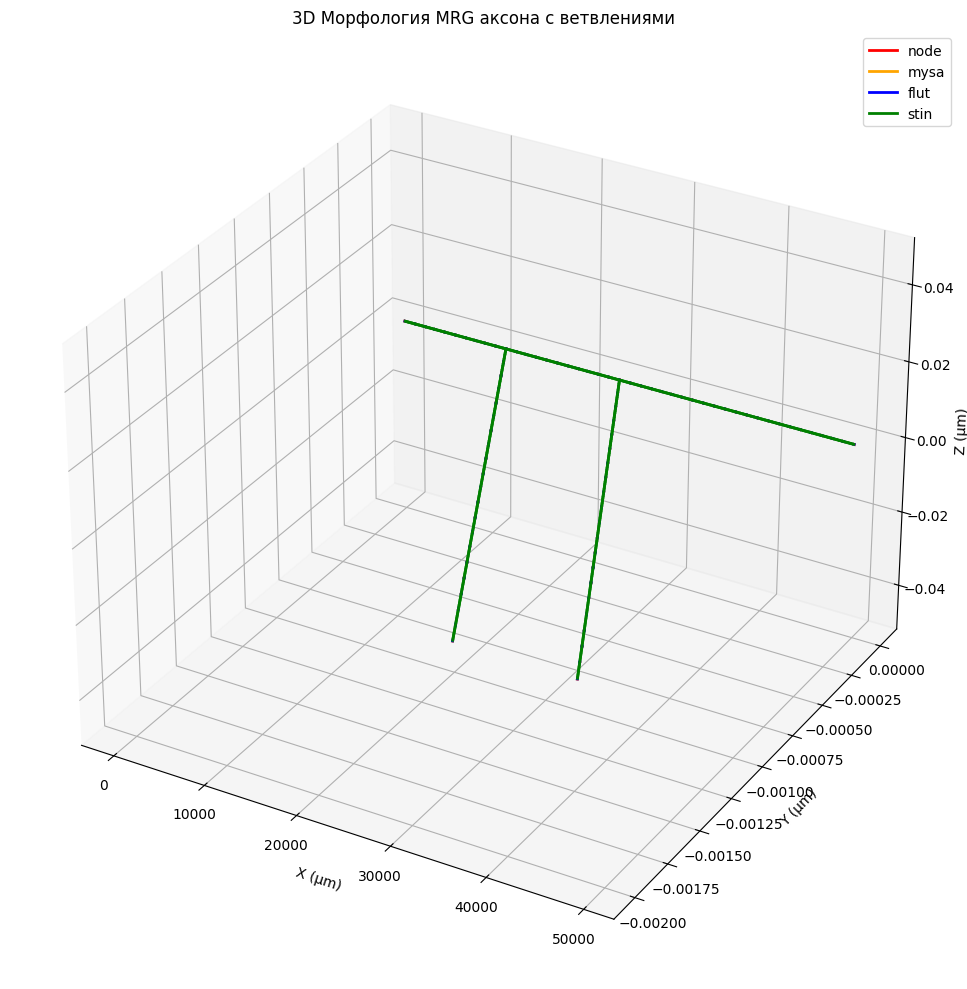

In [90]:

axon = MRGaxon(fiber_diameter=10.0,
             parent_axon_nodes=42,
             branch_nodes=21,
             branches_num=2,
             nodes_dist=10,
             diam_scale=0.6,
             celsius=37.0,
             dt_ms=0.05,
             v_init=-80.0,
             h_stop = 1000.0)

axon.plot_morphology_3d()

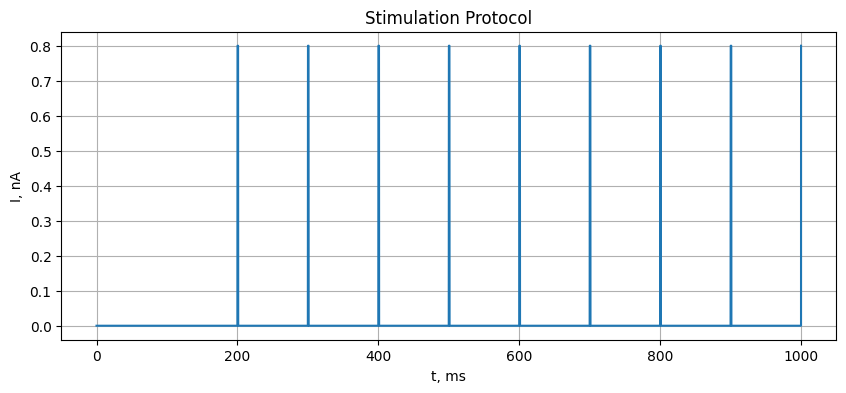

Stimulator: IClamp[9]
Section: node_0
Location: node_0(0.5)
Time vector size: 20001
Current vector size: 20001
First 10 time points: [0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45]
First 10 current points: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Created 9 stimulators
Changed dt
Всего секций в словаре: 920
Доступные секции: ['node_0', 'node_1', 'node_2', 'node_3', 'node_4', 'node_5', 'node_6', 'node_7', 'node_8', 'node_9', 'node_10', 'node_11', 'node_12', 'node_13', 'node_14', 'node_15', 'node_16', 'node_17', 'node_18', 'node_19']
Индексы для построения:
  До ветвления: [8, 42]
  После ветвления (основная): [36, 70]
  После ветвления (дочерняя): [15, 49]


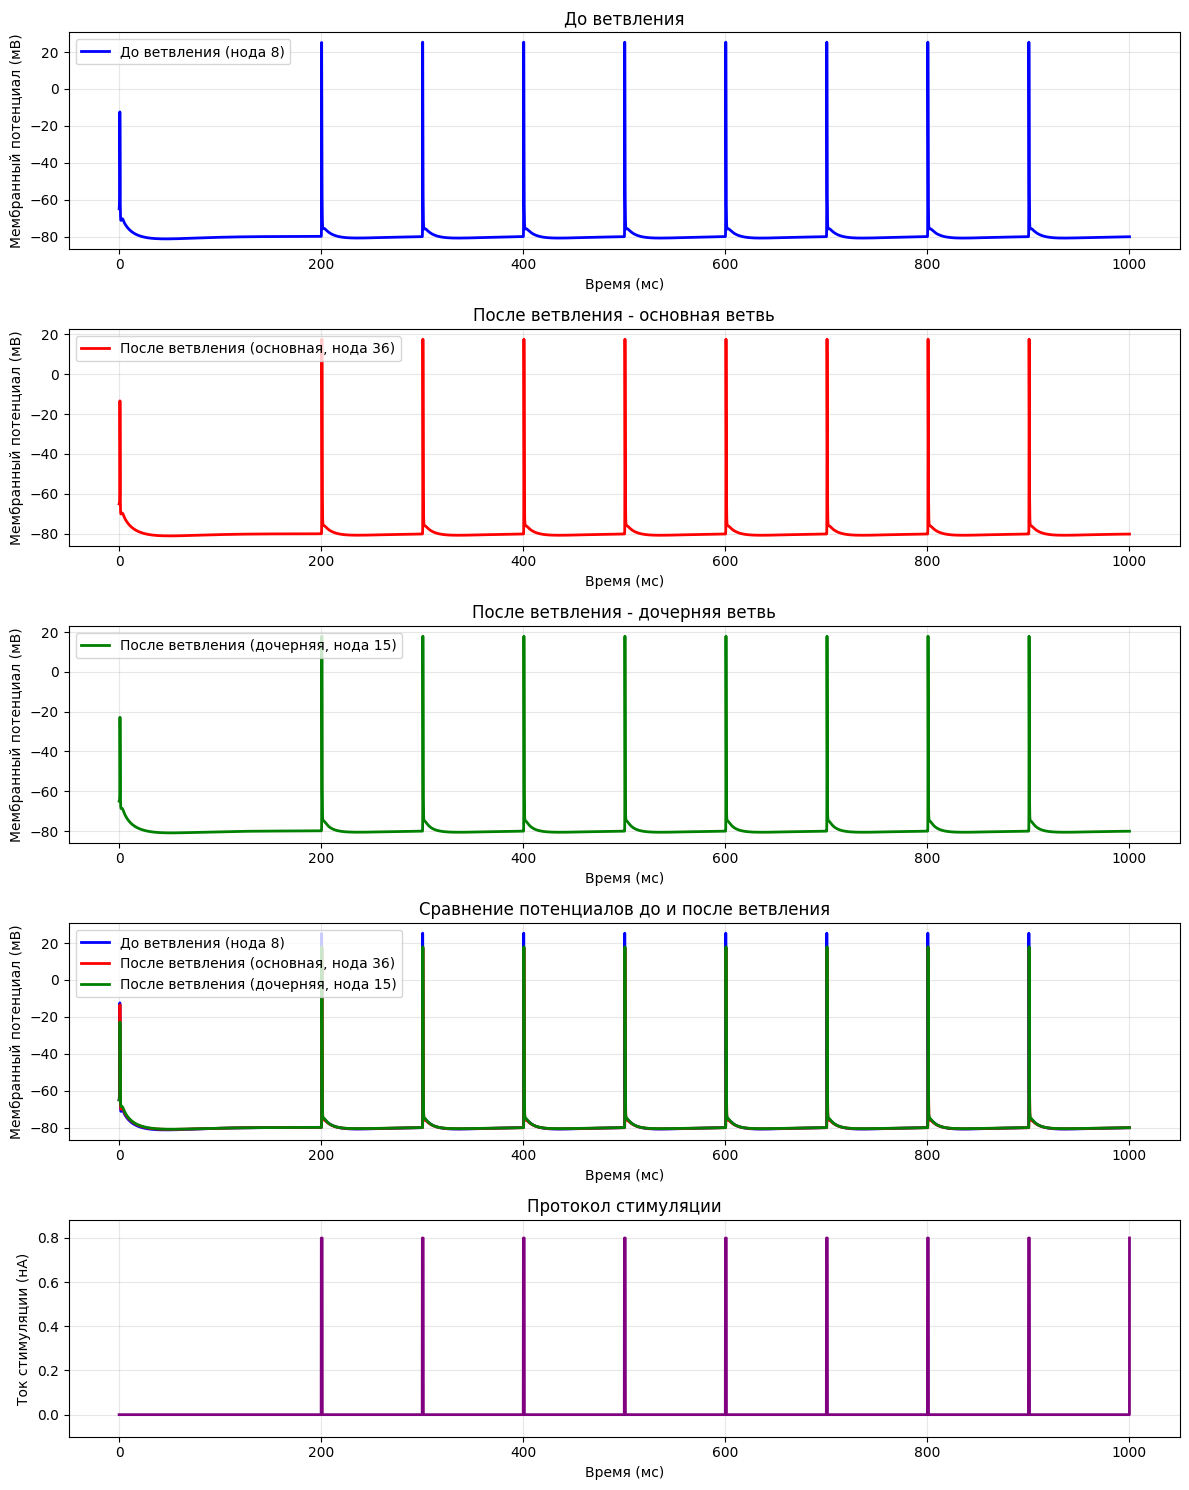

In [91]:
axon.run_simulation()
axon.plot_voltage_traces()

Ноды на которых будет вестись запись:
Ветвление в точке: []
3 ноды до точки ветвления: []
3 ноды после точки ветвления в главном аксоне: []
3 ноды после точки ветвления в дочерней ветке: []
